In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

as we are running all the operations on cpu so we will draw a subset of 6000 images from those 70000 images

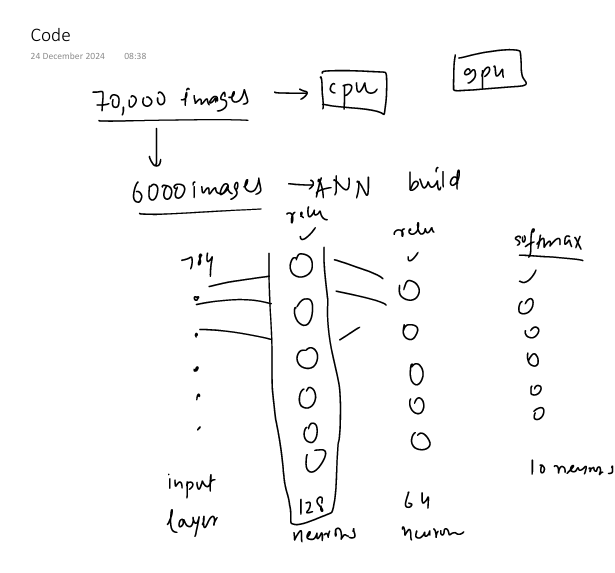

In [4]:
import gdown

# The file ID from your link
file_id = '1ziN7gJHnr-MQb0_eFsPfPfiiDuvsmqVH'
url = f'https://drive.google.com/uc?id={file_id}'

# Download directly to the Kaggle working directory
output = 'fmnist_small.csv'
gdown.download(url, output, quiet=False)

# Now load it with pandas
import pandas as pd
df = pd.read_csv('fmnist_small.csv')
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1ziN7gJHnr-MQb0_eFsPfPfiiDuvsmqVH
To: /kaggle/working/fmnist_small.csv
100%|██████████| 13.3M/13.3M [00:00<00:00, 33.5MB/s]


   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      9       0       0       0       0       0       0       0       0   
1      7       0       0       0       0       0       0       0       0   
2      0       0       0       0       0       0       1       0       0   
3      8       0       0       0       0       0       0       0       0   
4      8       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         7         0        50       205       196   
1       0  ...         0         0         0         0         0         0   
2       0  ...       142       142       142        21         0         3   
3       0  ...         0         0         0         0         0         0   
4       0  ...       213       203       174       151       188        10   

   pixel781  pixel782  pixel783  pixel784  
0       213       165         

In [5]:
# Set random seeds for reproducibility
torch.manual_seed(42)

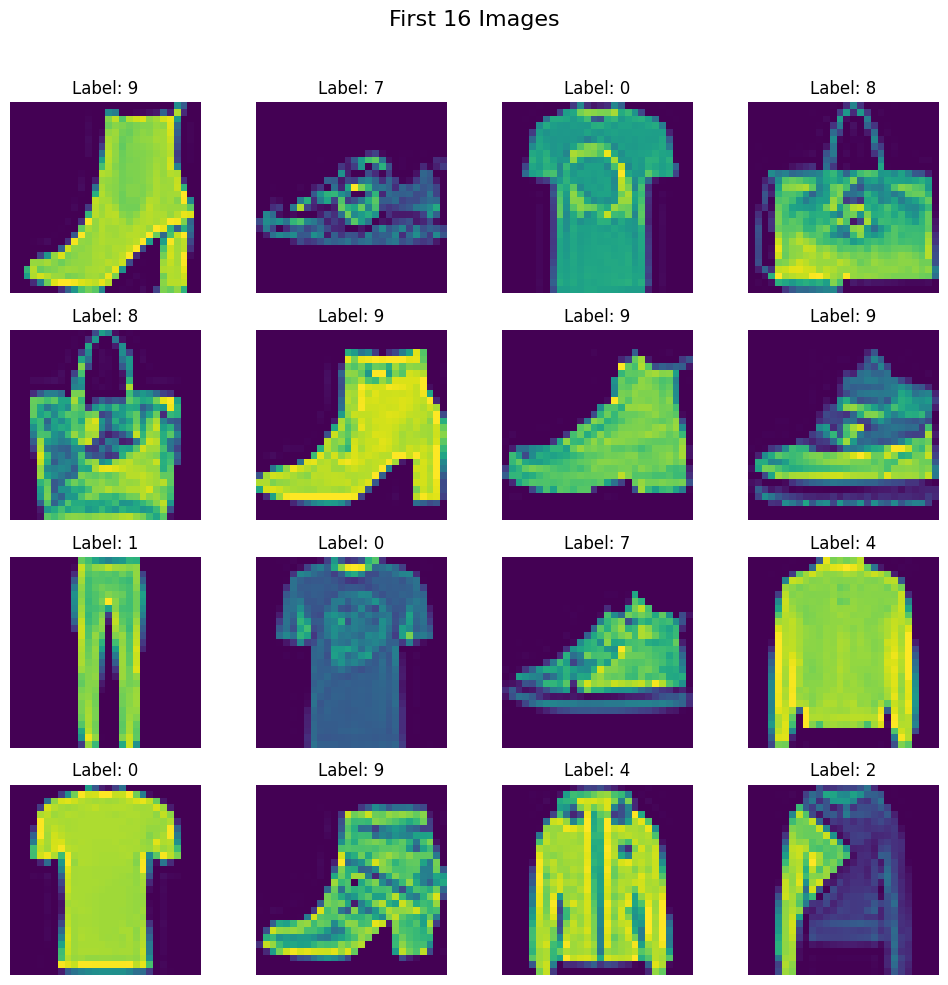

In [6]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [7]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# scaling the feautures
X_train = X_train/255.0
X_test = X_test/255.0

In [10]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [16]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [17]:
train_dataset = CustomDataset(X_train, y_train)

In [18]:
len(train_dataset)

4800

In [19]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [20]:
test_dataset = CustomDataset(X_test, y_test)

In [21]:
len(test_dataset)

1200

In [22]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [24]:
class MyNN(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(0),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64,10)
        )

    def forward(self, x):
        return self.model(x)

In [25]:
epochs = 100
learning_rate = 0.1

In [26]:
model = MyNN(X_train.shape[1])
#loss function
criterion = nn.CrossEntropyLoss()
#optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [28]:
#training loop
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_labels in train_loader:
        #forward pass
        outputs = model(batch_features)
        #calculate loss
        loss = criterion(outputs, batch_labels)
        #back pass
        optimizer.zero_grad()
        loss.backward()
        #update gradients
        optimizer.step()
        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    print(f'Epoch: {epoch + 1} , Loss: {avg_loss}')

Epoch: 1 , Loss: 1.3294126709302267
Epoch: 2 , Loss: 0.7638574061791102
Epoch: 3 , Loss: 0.6495985527833302
Epoch: 4 , Loss: 0.5794211247563362
Epoch: 5 , Loss: 0.5347444785634676
Epoch: 6 , Loss: 0.49549004505078
Epoch: 7 , Loss: 0.46407783567905425
Epoch: 8 , Loss: 0.4470512224237124
Epoch: 9 , Loss: 0.42121612568696337
Epoch: 10 , Loss: 0.4033399346470833
Epoch: 11 , Loss: 0.39007148722807566
Epoch: 12 , Loss: 0.3697173958023389
Epoch: 13 , Loss: 0.35994718288381894
Epoch: 14 , Loss: 0.3333256195982297
Epoch: 15 , Loss: 0.32545950725674627
Epoch: 16 , Loss: 0.30950973361730577
Epoch: 17 , Loss: 0.2999805728097757
Epoch: 18 , Loss: 0.28546400999029475
Epoch: 19 , Loss: 0.2788042150934537
Epoch: 20 , Loss: 0.2802167300879955
Epoch: 21 , Loss: 0.2520474964131912
Epoch: 22 , Loss: 0.24897550769150256
Epoch: 23 , Loss: 0.2336292164772749
Epoch: 24 , Loss: 0.2330006778240204
Epoch: 25 , Loss: 0.22235858539740244
Epoch: 26 , Loss: 0.21661974924306074
Epoch: 27 , Loss: 0.21290105976164342
E

In [29]:
#model evaluation
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [32]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.8308333333333333
